<a href="https://colab.research.google.com/github/uditnarayanpandey/Machine_Learning_Practice/blob/Master/Deep%20Learning/src/ANN_with_early_stopping/Early_Stopping_MNIST_Fashion_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MNIST Multiclass Clasification Using **ANN** - Fashion Dataset

---
This is just a sample code to learn the implementation of **Deep Learning Algorithms** using **Pytorch**

## **Importing Necessary Libraries**
---
Importing all the necessary libraries from pytorch and pandas to build an ANN on MNIST Fashion Dataset

In [12]:
# installing pytorchtools
!pip install pytorchtools

In [14]:
#importing numpy library
import numpy as np

# Importing torch libraries
import torch
from torch import nn
from torch.utils.data import Dataset
from torchvision import datasets
from torch.utils.data import SubsetRandomSampler
from torch.utils.data import DataLoader, random_split
from torchvision.transforms import ToTensor, Normalize, Compose
import matplotlib.pyplot as plt

In [2]:
#if GPU is available then utilise it
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(device)

cpu


## **User Defined Functions**

In [17]:
# Early Stopping Mechanism

class ValidationLossEarlyStopping:
    def __init__(self, patience=1, min_delta=0.0, verbose=False):
        self.patience = patience  # number of times to allow for no improvement before stopping the execution
        self.min_delta = min_delta  # the minimum change to be counted as improvement
        self.verbose = verbose  # whether to print verbose messages
        self.counter = 0  # count the number of times the validation accuracy not improving
        self.min_validation_loss = np.inf

    # return True when validation loss is not decreased by the `min_delta` for `patience` times
    def early_stop_check(self, validation_loss, model):
        if ((validation_loss + self.min_delta) < self.min_validation_loss):
            if self.verbose:
                print(f"Validation loss improved from {self.min_validation_loss:.6f} to {validation_loss:.6f}. Resetting counter... Saving Model")
            self.min_validation_loss = validation_loss
            self.counter = 0  # reset the counter if validation loss decreased at least by min_delta
        elif ((validation_loss + self.min_delta) > self.min_validation_loss):
            self.counter += 1  # increase the counter if validation loss is not decreased by the min_delta
            if self.verbose:
                print(f"Validation loss did not improve. Counter increased to {self.counter}.")
            if self.counter >= self.patience:
                if self.verbose:
                    print(f"Early stopping triggered after {self.patience} epochs with no improvement.")
                return True
        return False


## **Loading the Datasets**
---
Loading the dataset MINIST Fashion Dataset

In [3]:
def prepare_datasets(batch_size, validation_size):

    if validation_size is None:
        raise Exception("Please enter the right validation size. It can't be None")

    # loading the Train and Test dataset
    train_data = datasets.FashionMNIST(root="data",
                                       train=True,
                                       download=True,
                                       transform=ToTensor())

    test_data = datasets.FashionMNIST(root="data",
                                      train=False,
                                      download=True,
                                      transform=ToTensor())

    # split train dataset to Train and Validation
    # obtain training indices that will be used for validation
    train_length = len(train_data)
    indices = list(range(train_length))

    np.random.shuffle(indices)
    split = int(np.floor(validation_size * train_length))
    train_idx, valid_idx = indices[split:], indices[:split]

    # define samplers for obtaining training and validation batches
    train_sampler = SubsetRandomSampler(train_idx)
    valid_sampler = SubsetRandomSampler(valid_idx)

    train_loader = DataLoader(
                                train_data,
                                shuffle = False, # Note that shuffle=True can't be used while using SubsetRandomSampler
                                batch_size = batch_size,
                                sampler = train_sampler,
                                num_workers = 0
                             )

    valid_loader = DataLoader(
                                train_data,
                                shuffle = False, # Note that shuffle=True can't be used while using SubsetRandomSampler
                                batch_size = batch_size,
                                sampler = valid_sampler,
                                num_workers = 0
                             )

    test_loader = DataLoader(
                                test_data,
                                batch_size = batch_size,
                                num_workers = 0
                            )

    # this is for debugging
    print(f"Training data size : {train_idx.__len__()}")
    print(f"Validation data size : {valid_idx.__len__()}")
    print(f"Test data size : {test_loader.dataset.__len__()}")

    return train_loader, valid_loader, test_loader


In [4]:
train_loader, valid_loader, test_loader = prepare_datasets(64, 0.2)

100%|██████████| 26421880/26421880 [00:06<00:00, 4200246.88it/s]


Extracting data/FashionMNIST/raw/train-images-idx3-ubyte.gz to data/FashionMNIST/raw



100%|██████████| 29515/29515 [00:00<00:00, 135085.90it/s]


Extracting data/FashionMNIST/raw/train-labels-idx1-ubyte.gz to data/FashionMNIST/raw



100%|██████████| 4422102/4422102 [00:08<00:00, 518941.85it/s] 


Extracting data/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to data/FashionMNIST/raw



100%|██████████| 5148/5148 [00:00<00:00, 4857655.12it/s]

Extracting data/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to data/FashionMNIST/raw

Training data size : 48000
Validation data size : 12000
Test data size : 10000


## **Displaying Sample Images**
---
Displaying Sample Images from the Dataset.
> The entire expression **torch.randint(len(training_data), size=(1,)).item()** generates a random index within the range of the dataset size and returns it as a standard Python integer. This index can be used to randomly access a sample from the dataset.

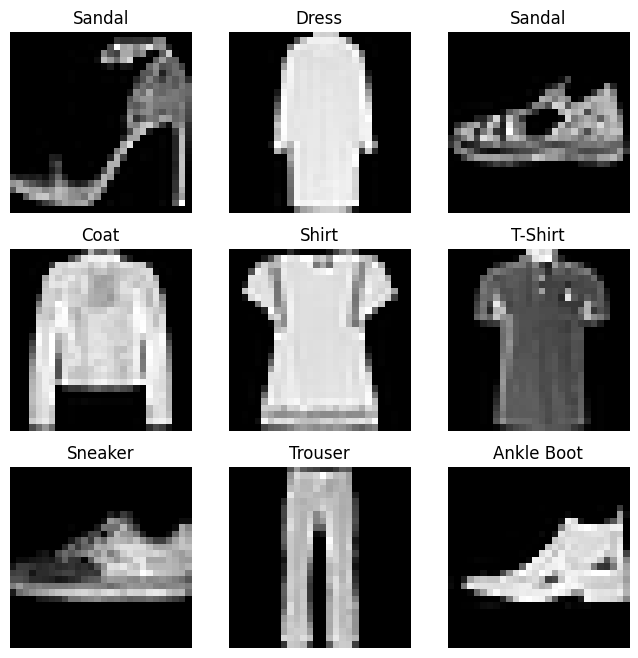

In [5]:
labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(train_loader), size=(1,)).item()
    img, label = train_loader.dataset[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

## **Defining the Neural Network**
---
Building a Neural Network Architecture to train the model. It's a simple MLP model (ANN)

> **Define the class** :

We define our neural network by subclassing nn.Module, and initialise the neural network layers in __init__. Every **nn.Module** subclass implements the operations on input data in the forward method.

In [6]:
class Net(torch.nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
                                                nn.Linear(28*28, 128)
                                                , nn.ReLU()
                                                , nn.Dropout(0.2)
                                                , nn.Linear(128, 128)
                                                , nn.ReLU()
                                                , nn.Dropout(0.2)
                                                , nn.Linear(64, 10)
                                              )


    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

model = Net()
print(model)

Net(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=10, bias=True)
  )
)


### **Initializing the weights and Biases**

In [7]:
def weight_init_normal(m):
    classname=m.__class__.__name__
    if classname.find('Linear')!=-1:
        n = m.in_features
        y = (1.0/np.sqrt(n))
        m.weight.data.normal_(0, y)
        m.bias.data.fill_(0)

model.apply(weight_init_normal)
print(model)

Net(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=10, bias=True)
  )
)


### **Specify Loss Function & Optimizer**

In [8]:
# specify the loss function
criterion = nn.CrossEntropyLoss()

# specify the optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

## **Train The Model Using Early Stopping**

In [ ]:
def train_model(model, patience, min_delta, n_epochs):
    """
    Description : This function train the Neural Network on the
                  train_data and validate it on valid_data
    """

    # to track the training loss and validation loss as the model trains
    loss_keeper = {'train_losses':[],
                   'valid_losses':[]}

    # to track average training and validation loss as the model trains
    avg_loss_keeper = {'avg_train_losses':[],
                        'avg_valid_losses':[]}

    # minimum validation loss ----- set initial minimum to infinity
    valid_loss_min = np.Inf

    # Early stopping mechanism
    ValidationLossEarlyStopping = ValidationLossEarlyStopping(patience = patience, min_delta = min_delta, verbose = True)

    for epoch in range(1, n_epochs+1):

        ###################
        # train the model #
        ###################
        model.train() # prep model for training
        for data, target in train_loader:
            if device == 'cuda':
                model = model.to(device)
                images,labels=data.to(device),target.to(device)
            # clear the gradients of all optimized variables
            optimizer.zero_grad()
            # forward pass: compute predicted outputs by passing inputs to the model
            output = model(data)
            #calcuate the loss
            loss = criterion(output, target)
            # backward pass: compute gradient of the loss with respect to model parameters
            loss.backward()
            # perform a single optimisation step (parameter update)
            optimizer.step()
            # record training loss
            loss_keeper['train_losses'].append(loss.item())

        ######################
        # validate the model #
        ######################
        model.eval() # prep model for evaluation
        for data, target in valid_loader:
            if device == 'cuda':
                model = model.to(device)
                images,labels=data.to(device),target.to(device)
            # forward pass: compute predicted outputs by passing inputs to the model
            output = model(data)
            # calculate the loss
            loss = criterion(output, target)
            # record validation loss
            loss_keeper['valid_losses'].append(loss.item())

        # print training/validation statistics
        # calculate average loss ove an epoch
        train_loss = np.average(loss_keeper['train_losses'])
        valid_loss = np.average(loss_keeper['valid_losses'])
        avg_loss_keeper['avg_train_losses'].append(train_loss)
        avg_loss_keeper['avg_valid_losses'].append(valid_loss)

        epoch_len = len(str(n_epochs))
        print_msg = (f'[{epoch:>{epoch_len}}/{n_epochs:>{epoch_len}}] ' +
                     f'train_loss: {train_loss:.5f} ' +
                     f'valid_loss: {valid_loss:.5f}')

        print(print_msg)

        # clear lists to track next epoch
        loss_keeper['train_losses'] = []
        loss_keeper['valid_losses'] = []


